# Zeeman Effect

Group 15:
- Bhawna Meena (23B1846)
- Farhan Ahmad (23B1847)
- Soham Sahasrabuddhe (23B1848)
- Chinmay Kale (23B1849)

# Aim
1. Finding the spacing between the reflecting plates Fabry-Perot interferometer
2. Observation of Zeeman splitting and calculation of Bohr magneton in Transverse mode
3. Observation of Zeeman splitting in Longitudinal mode

# Apparatus
The experimental setup consists of the following components:

- Mercury discharge lamp: Used as the source of spectral emission
- Electromagnet with constant current power supply: Used to generate a uniform magnetic field
- Optical rail with mounted optical components: Used to align all optical elements
- Infrared (IR) filter: Used to block infrared radiation from the mercury lamp
- Green filter: Used to isolate the mercury spectral line at **546.1 nm**
- Polarizer with slit: Used to select the required polarization component of the emitted light
- Fabry-Perot interferometer: Used to produce interference rings for precise wavelength measurement
- Focusing lens: Used to focus the interference pattern onto the detector
- CCD camera with image acquisition software: Used to capture and record the interference ring pattern

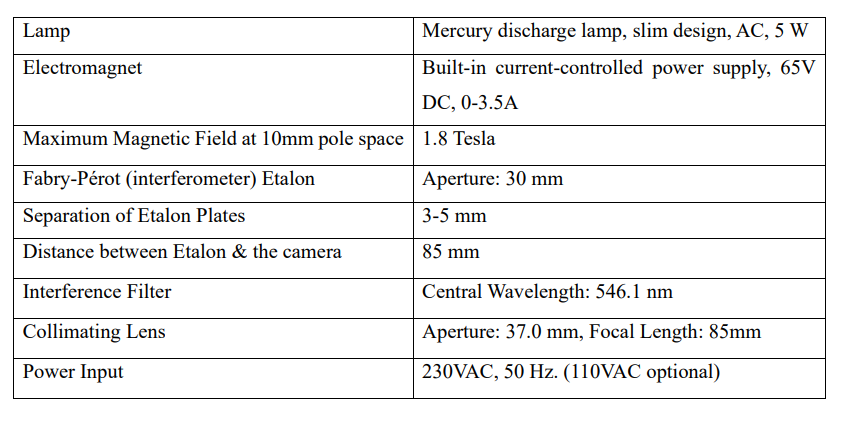

# Theory

Zeeman Effect refers to the splitting of atomic spectral lines when an atom is placed in an external magnetic field. This occurs because the magnetic moment associated with the angular momentum of electrons interacts with the applied magnetic field. In the absence of a magnetic field, atomic transitions produce a single spectral line. When a magnetic field is applied, the atomic energy levels split into several closely spaced levels, resulting in multiple spectral lines.


The orbital motion of an electron gives rise to a magnetic moment which is related to its orbital angular momentum:
$$ \vec{\mu}_L = \frac{e\hbar}{2m_e} \frac{\vec{L}}{\hbar}$$

The constant $$\mu_B = \frac{e\hbar}{2m_e}$$

is called the **Bohr magneton**, which represents the natural unit of the magnetic moment of an electron.

### Spin Magnetic Moment

The electron also possesses intrinsic angular momentum called spin. The magnetic moment associated with spin is
$$\vec{\mu}_S = g_S \mu_B \frac{\vec{S}}{\hbar}$$

where

- $g_S$ = spin Landé factor
- $\vec{S}$ = spin angular momentum

Hence the total angular momentum of an electron is
$$\vec{J} = \vec{L} + \vec{S}$$

The magnetic moment associated with total angular momentum is
$$\vec{\mu}_J = g_J \mu_B \frac{\vec{J}}{\hbar}$$

where $g_J$ is called the **Landé g-factor**. This determines the magnitude of splitting of atomic energy levels in a magnetic field and is given by
$$g_J = 1 + \frac{J(J+1) + S(S+1) - L(L+1)}{2J(J+1)}$$

where

- $L$ = orbital angular momentum quantum number  
- $S$ = spin angular momentum quantum number  
- $J$ = total angular momentum quantum number

### Energetic Changes
When an external magnetic field $B$ is applied, the interaction between the magnetic moment and the magnetic field changes the atomic energy:
$$\Delta E = \vec{\mu}_J \cdot \vec{B}$$
And we know that, $$ \Delta E = g_J m_J \mu_B B$$

with $m_J$ = magnetic quantum number and $B$ = magnetic field strength.

For transitions corresponding to \(m_J = +1\) and \(m_J = -1\), the difference in energy becomes
$$\Delta E = 2 \mu_B B (g_{JH} - g_{JL})$$

where
- $g_{JH}$ = Landé factor of higher energy level  
- $g_{JL}$ = Landé factor of lower energy level

### Fabry-Perot Interferometer

A Fabry-Perot interferometer** consists of two parallel partially reflecting plates separated by a small distance. Multiple reflections between these plates produce interference fringes in the form of concentric circular rings. These rings allow measurement of very small differences in wavelength. The spacing between the reflecting plates is given by
$$d = \frac{\lambda F^2}{2(\chi_{n-1}^2 - \chi_n^2)}$$

where $d$ is spacing between reflecting plates, $F$ is focal length of the lens, $\lambda$ is wavelength of light, and $\chi_n$ is radius of the $n^{th}$ interference ring

### Energy Difference from Ring Radii

The difference in energy between the split spectral lines can be obtained from the radii of the interference rings: $$ \Delta E = \frac{hc(\chi_{n+}^2 - \chi_{n-}^2)}{2\lambda F^2}$$
From the measured splitting, the **Bohr magneton** can be calculated using
$$\mu_B = \frac{hc(\chi_{n+}^2 - \chi_{n-}^2)}{4(g_{JH} - g_{JL}) \lambda F^2 B}$$

This value is compared with the theoretical value $$ \mu_B = 9.274 \times 10^{-24} \; J/T$$

# Analysis

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Constants
pixel_scale = 3.9 # 1 pixel = 3.9 um
lam = 546.1e-3 # wavelength = 546.1 nm
F = 85e3 # focal length = 85 mm
h = 6.626e-34
c = 3e8
B1 = 13490 # Gauss for 2.75 A
B2 = 14320 # Gauss for 3 A
gjH = 2 # 6s7s 3S1
gjL = 3/2 # 6s7s 3P2

## Part 1: Finding d

In [3]:
df = pd.read_csv('0A.csv')
pixels = df['Length'].to_numpy()
chi = pixels * pixel_scale
chi_sq = chi**2
delta = chi_sq[1:] - chi_sq[:-1]
d = (lam * F**2) / delta
average_d = np.mean(d)

print("Computed d values:", d)
print(f"Average d = {average_d:.4f} micrometers")

Computed d values: [3702.39367475 4045.88038647 3457.85029024]
Average d = 3735.3748 micrometers


## Part 2: Finding $|\vec{\mu_B}|$

### 2.75 A case

In [4]:
df_raw = pd.read_csv('2.75A.csv')
pixels = df_raw['Length'].to_numpy()
chi = pixels * pixel_scale
chi_plus = chi[1::2]
chi_minus = chi[::2]
chi_plus_sq = chi_plus**2
chi_minus_sq = chi_minus**2
delta = chi_plus_sq - chi_minus_sq

# Bohr Magneton value
mu_B = (h*c*delta)*1e10/(4*(gjH-gjL)*lam*F**2*B1)
mu_B_avg = np.mean(mu_B)

results_df = pd.DataFrame({
    'chi_plus': chi_plus,
    'chi_minus': chi_minus,
    'chi_plus_sq': chi_plus_sq,
    'chi_minus_sq': chi_minus_sq,
    'delta': delta,
    'mu_B': mu_B})

print("Calculation Table for 2.75A:")
display(results_df)

print(f"\nAverage mu_B = {mu_B_avg:.4e} J/T")

Calculation Table for 2.75A:


,chi_plus,chi_minus,chi_plus_sq,chi_minus_sq,delta,mu_B
0,1758.2019,1608.4068,3.091274e+06,2.586972e+06,504301.486877,9.416965e-24
1,2037.3990,1931.3307,4.150995e+06,3.730038e+06,420956.412439,7.860639e-24
2,2304.1824,2193.3951,5.309257e+06,4.810982e+06,498274.467766,9.304421e-24
3,2510.1102,2432.1102,6.300653e+06,5.915160e+06,385493.191200,7.198424e-24



Average mu_B = 8.4451e-24 J/T


In [5]:
# Error Analysis
mu_B_th = 9.274e-24
percent_error = np.abs(mu_B_th - mu_B_avg)/mu_B_th
print("Percent error_2.75 =", percent_error*100)

Percent error_2.75 = 8.937759232711299


### 3 A case

In [6]:
df_raw = pd.read_csv('3A.csv')
pixels = df_raw['Length'].to_numpy()
chi = pixels * pixel_scale
chi_plus = chi[1::2]
chi_minus = chi[::2]
chi_plus_sq = chi_plus**2
chi_minus_sq = chi_minus**2
delta = chi_plus_sq - chi_minus_sq

# Bohr Magneton value
mu_B = (h*c*delta)*1e10/(4*(gjH-gjL)*lam*F**2*B1)
mu_B_avg = np.mean(mu_B)

results_df = pd.DataFrame({
    'chi_plus': chi_plus,
    'chi_minus': chi_minus,
    'chi_plus_sq': chi_plus_sq,
    'chi_minus_sq': chi_minus_sq,
    'delta': delta,
    'mu_B': mu_B})

print("Calculation Table for 3A:")
display(results_df)

print(f"\nAverage mu_B = {mu_B_avg:.4e} J/T")

Calculation Table for 3A:


,chi_plus,chi_minus,chi_plus_sq,chi_minus_sq,delta,mu_B
0,1719.2058,1592.2686,2.955669e+06,2.535319e+06,420349.288208,7.849302e-24
1,1981.8942,1893.4773,3.927905e+06,3.585256e+06,342648.334378,6.398370e-24
2,2233.5807,2139.6609,4.988883e+06,4.578149e+06,410733.976424,7.669752e-24
3,2454.4377,2377.4010,6.024264e+06,5.652036e+06,372228.908380,6.950736e-24



Average mu_B = 7.2170e-24 J/T


In [7]:
# Error Analysis
mu_B_th = 9.274e-24
percent_error = np.abs(mu_B_th - mu_B_avg)/mu_B_th
print("Percent error_3 =", percent_error*100)

Percent error_3 = 22.1798568316572


## Part 3: Longitudinal



- 0A

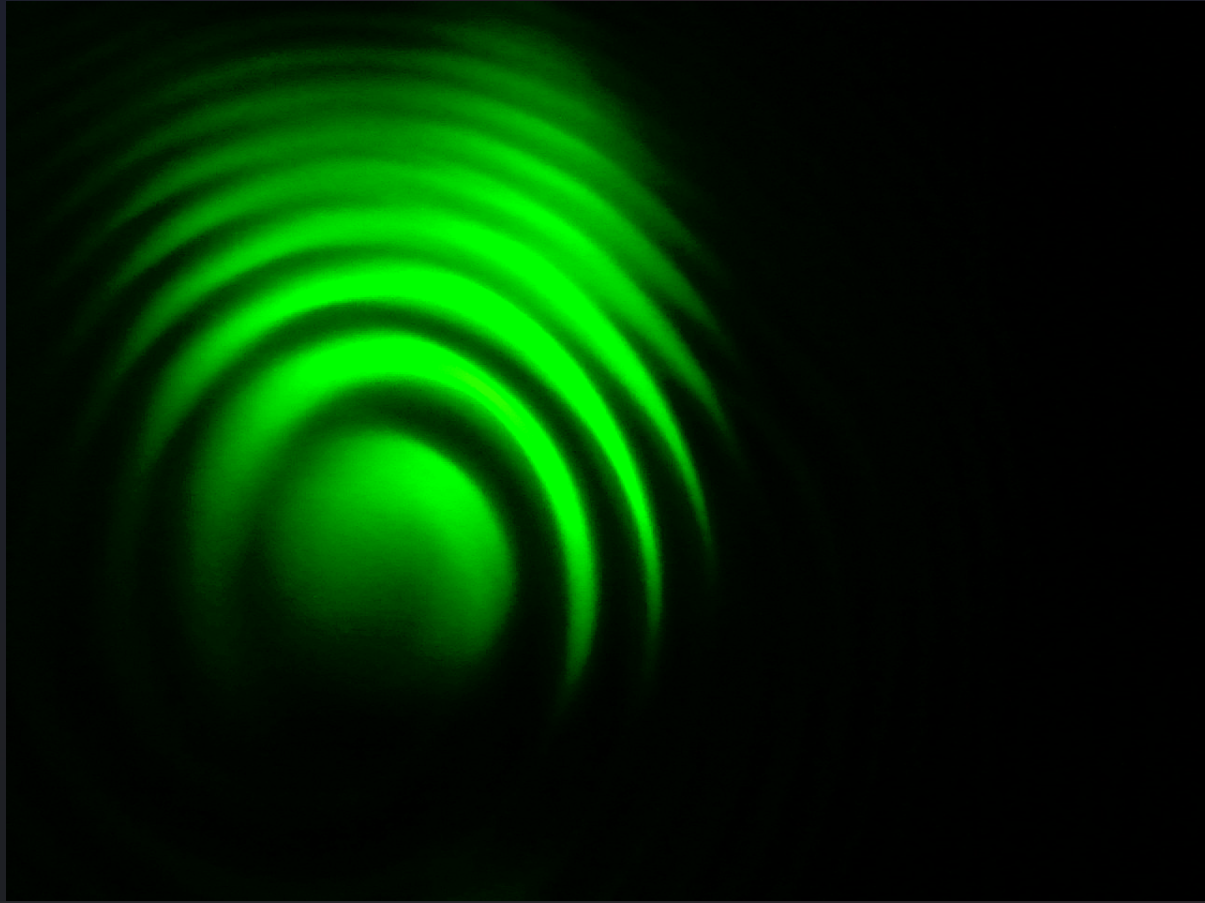

- 1A

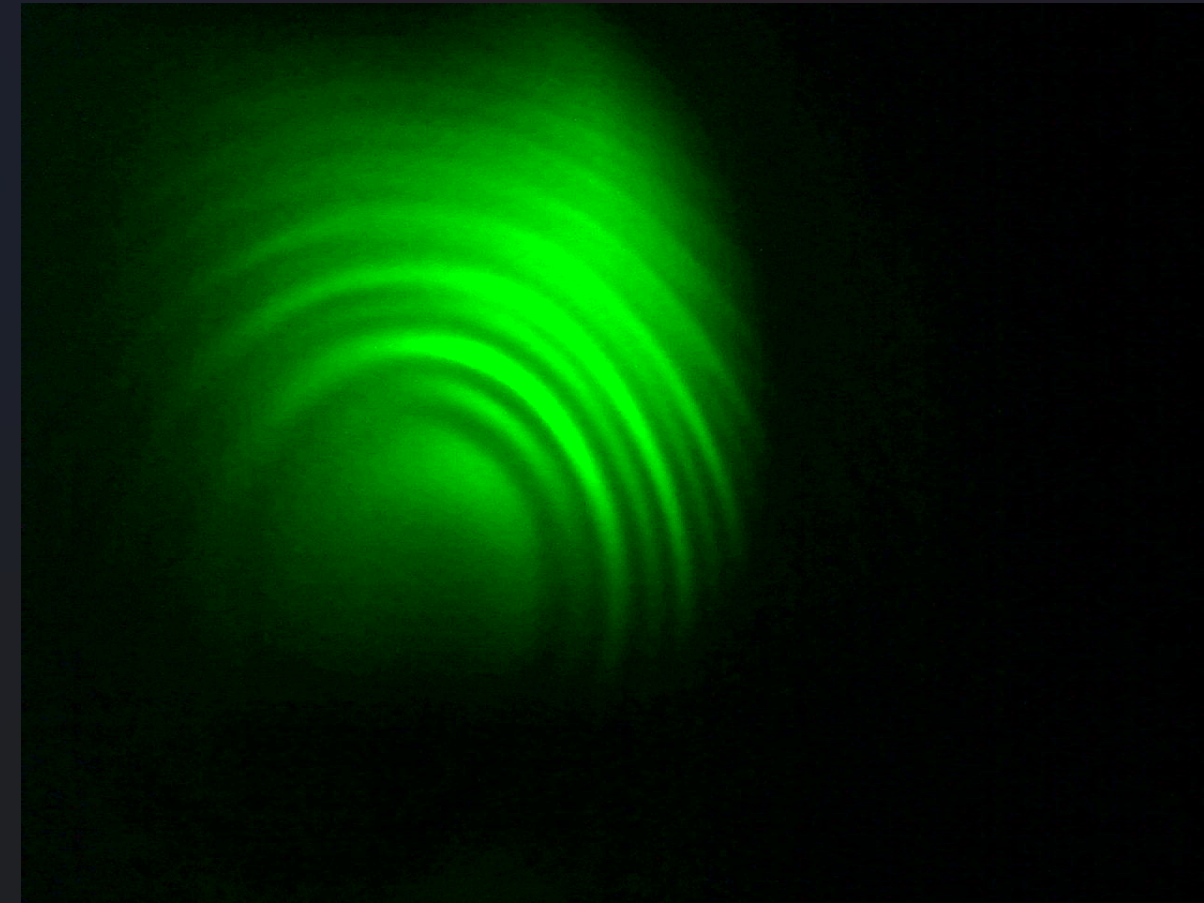

- 1A at $45°$

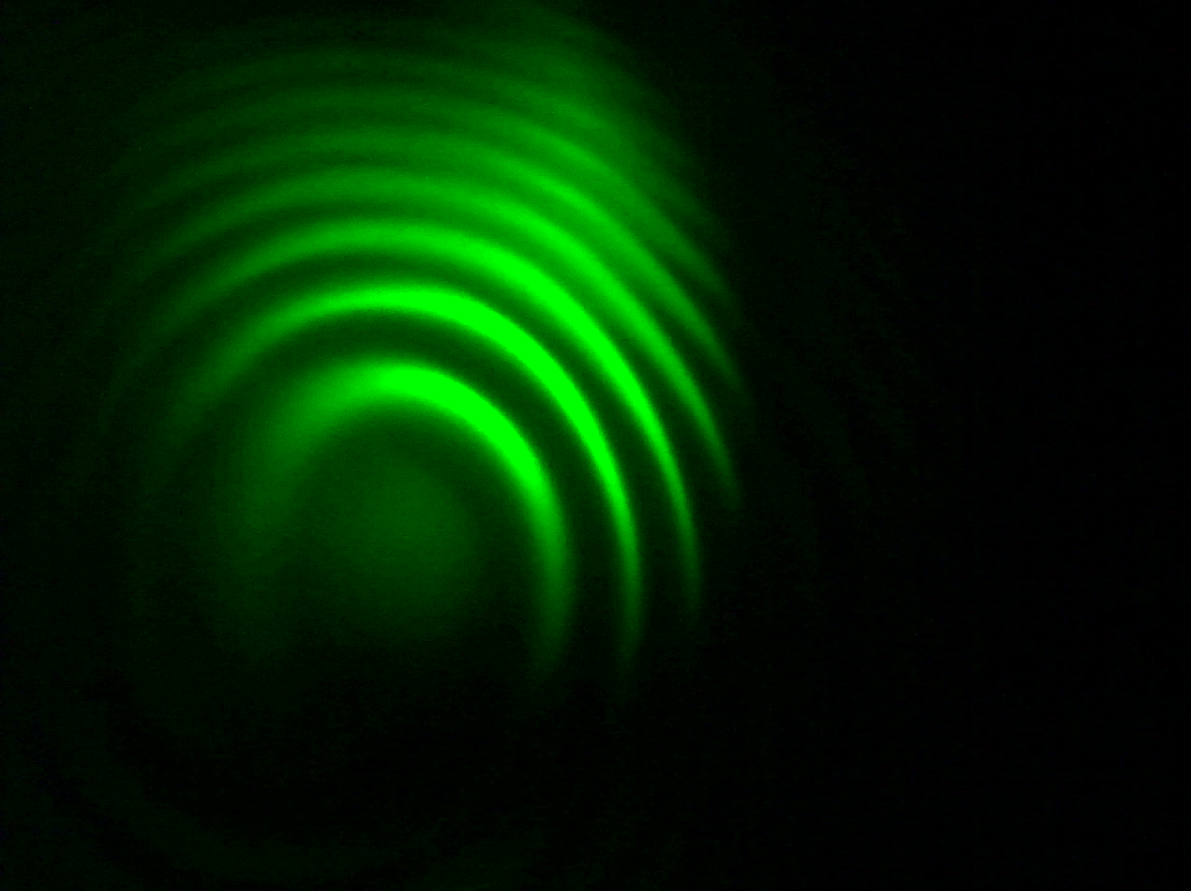

- 1A at 135°


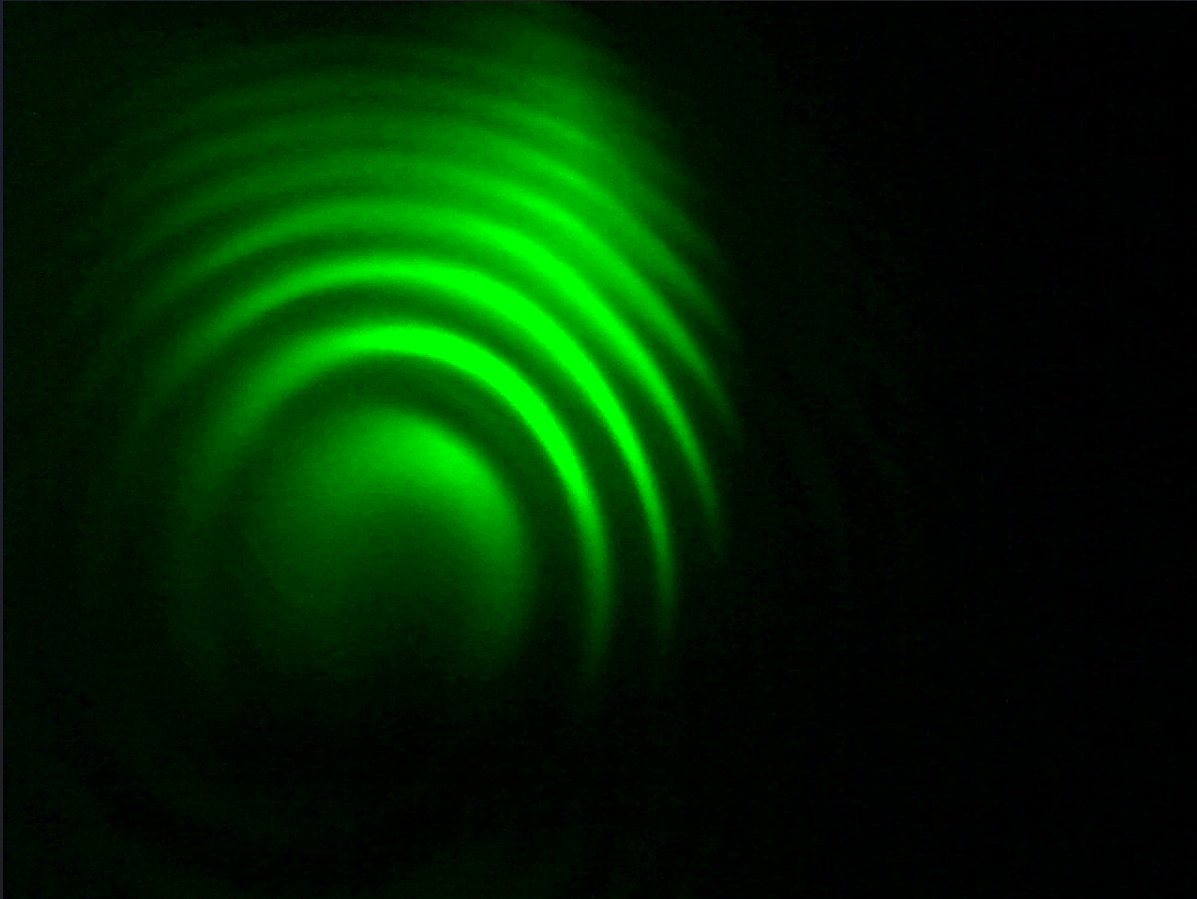

# Precautions

1. The mercury lamp should be turned on first and allowed to stabilize before taking any measurements

2. The CCD camera should be connected properly and the resolution should be set to the specified value while adjusting the interference rings

3. If the rings appear too dark, the exposure time should be increased or the slit width should be slightly adjusted

4. The Fabry-Perot interferometer must be carefully aligned using the kinematic screws so that the circular interference rings are centered on the screen

5. The slit should be kept as small as possible to obtain sharp interference fringes

6. Images should be captured at the specified resolution and saved properly for later analysis

7. While applying the magnetic field, the current in the electromagnet should not be kept high for more than two minutes to prevent overheating

8. The polarizer should be rotated carefully in transverse mode so that only the required Zeeman components are observed

# Results and Conclusions
1. The spacing between the reflecting plates Fabry-Perot interferometer is, d = 3.735 mm

2. Bohr magneton value, $\mu_B = 8.445112208758355 \times 10^{-24}$ J/T with 8.937% error for current value 2.75 A
3. Bohr magneton value, $\mu_B = 7.2170 \times 10^{-24}$ J/T with 22.18% error for current value 3 A

\
The experimentally obtained value of the Bohr magneton is $ 8.45 \times 10^{-24} $ J/T which is in reasonable agreement with the accepted value with a percentage error of approximately 9%. The deviation can be attributed to uncertainties in ring radius measurement and magnetic field calibration majorly.